<a href="https://colab.research.google.com/github/ParkHangah/AIFFEL_quest_eng/blob/master/NLP/NLP03/%EC%B1%97%EB%B4%87%EA%B5%AC%ED%98%84_VR03.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project: 멋진 챗봇 만들기

### 0. 환경 구성

#### 0-1. 코랩에서 터미널 라이브러리 설치 하기

In [1]:
!pip install kiwipiepy sentencepiece nltk transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 27.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 117.3 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.22.1-py3-none-any.whl size=79578111 sha256=58e4108f5409de80130bda4c90685ae6f33ee023c7addebc97937d9c1fcdc978
  Stored in directory: /root/.cache/pip/wheels/c0/5a/4b/a1abeb73f3d31c5d010d4163bc08686d5539766084ecba0e1a
Successfully built kiwipiepy_model


In [2]:
import kiwipiepy
import sentencepiece
import nltk
import transformers

# NLTK 데이터 다운로드 (필요한 경우)
nltk.download('punkt')

print("모든 라이브러리가 성공적으로 설치되었습니다!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


모든 라이브러리가 성공적으로 설치되었습니다!


#### 0-2. 환경 설정 & 라이브러리 임포트

In [3]:
# =========================================
# 0. 환경 설정 & 라이브러리 임포트
# =========================================
import os
import re
import math
import random
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from kiwipiepy import Kiwi            # 형태소 분석기 (mecab 대체)
import sentencepiece as spm
from tqdm import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

from transformers import get_cosine_schedule_with_warmup

import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib as mpl
from matplotlib import font_manager
import platform
import os

import warnings


In [4]:
# 1. 특정 경고 메시지 무시 설정
# Seaborn이나 IPython에서 하단 블록 문자(Glyph 9601, ' ')를 출력할 때
# 폰트 미지원으로 발생하는 경고를 숨깁니다.
warnings.filterwarnings(
    "ignore",
    message="Glyph 9601",
    module="seaborn.utils"
)
warnings.filterwarnings(
    "ignore",
    message="Glyph 9601",
    module="IPython.core.pylabtools"
)

# 2. 운영체제별 한글 폰트 설정
# 실행 중인 OS를 확인하여 Matplotlib에 적합한 한글 폰트를 지정합니다.
system = platform.system()

if system == "Windows":
    mpl.rcParams["font.family"] = "Malgun Gothic"  # 윈도우 기본 한글 폰트
elif system == "Darwin":
    mpl.rcParams["font.family"] = "AppleGothic"
else:
    # Linux 등 기타 OS는 별도의 폰트 설정이 필요함 (예: NanumGothic)
    pass

# 3. 유니코드 마이너스 기호 설정
# 폰트 변경 시 그래프의 축에서 마이너스(-) 기호가 깨지는 현상을 방지합니다.
mpl.rcParams["axes.unicode_minus"] = False

# 4. PyTorch 연산 장치(Device) 설정
# GPU(NVIDIA CUDA) 사용 가능 여부를 확인하여 장치를 할당합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
# 재현성 고정
# 1. 난수 생성을 위한 시드(Seed) 번호 설정
# 어떤 숫자를 써도 상관없지만, 관습적으로 42를 가장 많이 사용합니다.
SEED = 42

random.seed(SEED)         # 2. Python 기본 random 모듈의 시드 고정
np.random.seed(SEED)      # 3. NumPy 라이브러리의 시드 고정 (행렬 연산 등)
torch.manual_seed(SEED)   # 4. PyTorch의 CPU 연산 시드 고정
if device.type == "cuda": # 5. GPU 연산을 사용하는 경우, 모든 GPU 장치에 대해 시드 고정
    torch.cuda.manual_seed_all(SEED)


#### 0-3. 코랩 사용자를 위한 드라이브 연결

##### (1) 경로 설정을 사용사 환경에 맞게 해주세요

In [6]:
# 드라이브 경로 설정  by 박항아
drive_path = '#Study/Aiffel/Work' # 평상시 작업하는 드라이브 폴더 경로를 입력해 주세요.
project_name = 'transformer'       # 이번 프로젝트세 사용하는 폴더명을 입력해주세요.

##### (2) 드라이브 연결

In [ ]:
from google.colab import drive
from IPython.display import clear_output
import ipywidgets as widgets
import os

def inf(msg, style, wdth):
    inf = widgets.Button(description=msg, disabled=True, button_style=style, layout=widgets.Layout(min_width=wdth))
    display(inf)

# 1. 구글 드라이브 마운트
print("Connecting...")
drive.mount('/content/gdrive')

# 2. 경로 설정 및 폴더 생성
base_path = os.path.join('/content/gdrive/MyDrive',drive_path)
project_path = os.path.join(base_path, project_name)

# Create the project directory if it doesn't exist
os.makedirs(project_path, exist_ok=True)

print(f"base_path: {base_path}")
# 3. 폴더 생성
print(f"Selected Google Drive root path: {base_path}")
inf('\u2714 Done','success', '50px')

In [8]:
# 4. 작업 디렉토리 이동 및 다운로드
# !cd 대신 %cd를 사용해야 이후의 명령어들이 이 경로에서 실행됩니다.
%cd "{project_path}"
print(project_path)

/content/gdrive/MyDrive/#Study/Aiffel/Work/transformer
/content/gdrive/MyDrive/#Study/Aiffel/Work/transformer


### 1. 데이터 적재 및 전처리 (데이터 추가) *

In [58]:
import pandas as pd  # 엑셀 데이터를 처리하기위해 pandas 불러오
DATA_PATH = os.path.join(project_path,"data", "ChatbotData.csv")  # 경로에 맞게 수정 프로젝트Path + 데이터폴더 경로 + 데이터 파일명
# 업로드하신 새 파일 경로 (파일명이 길 경우 환경에 맞춰 수정 필요)
# NEW_DATA_PATH = os.path.join(project_path, "data", "Wellness Dataset - Dr.Fatma M. Talaat.xlsx")

In [59]:
# =========================================
# 1. 데이터 로드 & 전처리 (Chatbot_data.csv)
#    - songys/Chatbot_data 사용
# =========================================

# 1. 기존 데이터 불러오기
assert os.path.exists(DATA_PATH), "Chatbot_data.csv 준비 필요!"
df = pd.read_csv(DATA_PATH)
# 컬럼: Q(질문), A(답변), label 등으로 되어 있음
df = df[["Q", "A"]].dropna()
print("원본 데이터 개수:", len(df))

df_orig = df.copy() # 원본 데이터 프레임을 저장

# # 2. 추가 데이터 불러오기 및 변환
# if os.path.exists(NEW_DATA_PATH):
#     df_new = pd.read_excel(NEW_DATA_PATH) # CSV 대신 Excel 파일 읽기

#     # [분석] 업로드하신 데이터는 수치 데이터이므로 챗봇 학습을 위해 문장형으로 변환합니다.
#     # 예시: 질문에는 '수면 시간', 답변에는 '기분(Mood Output)'을 매칭
#     # 만약 다른 웰니스 Q&A 파일을 받으셨다면 컬럼명만 수정하면 됩니다.
#     if 'Duration of Sleep (hours)' in df_new.columns and 'Mood Output' in df_new.columns:
#         df_new_processed = pd.DataFrame()
#         df_new_processed['Q'] = "잠을 " + df_new['Duration of Sleep (hours)'].astype(str) + "시간 자면 기분이 어때?"
#         df_new_processed['A'] = "그럴 땐 보통 " + df_new['Mood Output'] + " 상태가 됩니다."

#         # 4. 데이터 합치기 (Concatenate)
#         # ignore_index=True를 통해 인덱스를 0부터 다시 재정렬합니다.
#         df = pd.concat([df_orig, df_new_processed], axis=0, ignore_index=True)
#         print(f"추가된 데이터 개수: {len(df_new_processed)}")
#     else:
#         # 만약 컬럼이 이미 Q, A 형식을 갖춘 다른 파일이라면 바로 합침
#         # 필요한 컬럼만 추출 (원본에 Q, A가 있다고 가정)
#         df_new = df_new.rename(columns={'Question': 'Q', 'Answer': 'A'}) # 컬럼명이 다를 경우 대비
#         df = pd.concat([df_orig, df_new[['Q', 'A']]], axis=0, ignore_index=True)
# else:
#     print("새로운 데이터 파일을 찾을 수 없습니다. 기존 데이터만 사용합니다.")
#     df = df_orig

# # 3. 최종 정제 및 결과 확인
# df = df.dropna().drop_duplicates().reset_index(drop=True)
# print("최종 통합 데이터 개수:", len(df))

# # 데이터 샘플 확인
# print(df.tail())

원본 데이터 개수: 11823


In [60]:
# -----------------------------------------
# 1-1. 한글 정규화 & 기본 전처리 함수
# -----------------------------------------
def clean_korean_text(text: str) -> str:
    text = str(text).strip()
    # 자모 분리/이상한 문자 제거 등 간단 처리
    text = re.sub(r"[^ㄱ-ㅎ가-힣0-9a-zA-Z\?\!\.\,\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Q_clean"] = df["Q"].apply(clean_korean_text)
df["A_clean"] = df["A"].apply(clean_korean_text)

# 너무 짧거나 긴 문장 제거
df = df[(df["Q_clean"].str.len() >= 2) & (df["Q_clean"].str.len() <= 50)]
df = df[(df["A_clean"].str.len() >= 2) & (df["A_clean"].str.len() <= 50)]

print("1차 정제 후 개수:", len(df))

1차 정제 후 개수: 11787


### 2. 형태소 분석 및 토큰 수준 정제

In [61]:
# =========================================
# 2. 형태소 분석 + 토큰 수준 정제 (Kiwi)
#    - mecab 대신 Kiwi 사용
# =========================================
kiwi = Kiwi()

def kiwi_tokenize(text: str):
    # 간단히 명사/동사/형용사 위주로 사용 (원하면 품사 필터링 조정)
    tokens = []
    for tok, pos, _, _ in kiwi.analyze(text, top_n=1)[0][0]:
        if pos.startswith("NN") or pos.startswith("VV") or pos.startswith("VA") or pos.startswith("MAG") or pos.startswith("IC"):
            tokens.append(tok)
        else:
            # 조사/어미 등도 포함하고 싶으면 주석 해제
            tokens.append(tok)
            pass
    # 토큰이 너무 적으면 원문 그대로 fallback
    if len(tokens) < 2:
        return text.split()
    return tokens

def join_tokens(tokens):
    return " ".join(tokens)

df["Q_tok"] = df["Q_clean"].apply(kiwi_tokenize)
df["A_tok"] = df["A_clean"].apply(kiwi_tokenize)

# 토큰 리스트를 다시 공백 기준 문장으로 변환 (SentencePiece 학습용)
df["Q_proc"] = df["Q_tok"].apply(join_tokens)
df["A_proc"] = df["A_tok"].apply(join_tokens)

print("토큰 예시 Q:", df["Q_proc"].iloc[0])
print("토큰 예시 A:", df["A_proc"].iloc[0])

토큰 예시 Q: 12 시 땡 !
토큰 예시 A: 하루 가 또 가 네요 .


### 3. 데이터 증강

In [62]:
# =========================================
# 3. 데이터 증강 (augmentation)
#    - 간단한 방식: 역질문 추가, 일부 단어 드랍, 순서 스왑 등
#    - 목표: 약 3만 문장 쌍 (질문-답변) 확보
# =========================================
pairs = list(zip(df["Q_proc"].tolist(), df["A_proc"].tolist()))
print("원본 쌍 개수:", len(pairs))

def random_drop_tokens(tokens, drop_prob=0.05):
    if len(tokens) <= 3:
        return tokens
    new_tokens = []
    for t in tokens:
        if random.random() < drop_prob:
            continue
        new_tokens.append(t)
    if len(new_tokens) < 2:
        return tokens
    return new_tokens

def random_swap_tokens(tokens, swap_prob=0.05):
    tokens = tokens[:]
    n = len(tokens)
    for i in range(n - 1):
        if random.random() < swap_prob:
            j = min(n - 1, i + 1)
            tokens[i], tokens[j] = tokens[j], tokens[i]
    return tokens

aug_pairs = []

for q, a in pairs:
    aug_pairs.append((q, a))  # 원본

    # 1) Q 토큰 드랍
    q_toks = q.split()
    a_toks = a.split()
    q_drop = " ".join(random_drop_tokens(q_toks))
    aug_pairs.append((q_drop, a))

    # 2) A 토큰 드랍
    a_drop = " ".join(random_drop_tokens(a_toks))
    aug_pairs.append((q, a_drop))

    # 3) Q/A 둘 다 스왑
    q_swap = " ".join(random_swap_tokens(q_toks))
    a_swap = " ".join(random_swap_tokens(a_toks))
    aug_pairs.append((q_swap, a_swap))

# 중복 제거
aug_pairs = list(set(aug_pairs))
print("증강 후 쌍 개수:", len(aug_pairs))

# 3만 개 가까이 맞추기 (필요시 샘플링)
TARGET_SIZE = 30000
if len(aug_pairs) > TARGET_SIZE:
    aug_pairs = random.sample(aug_pairs, TARGET_SIZE)

print("최종 사용 쌍 개수:", len(aug_pairs))

원본 쌍 개수: 11787
증강 후 쌍 개수: 26040
최종 사용 쌍 개수: 26040


### 4. 토크나이저 학습 (일부 변경-코랩사용자를 위해 코퍼스 파일 생성 경로를 project_path + 파일명으로 바꿈) *

In [64]:
# =========================================
# 4. SentencePiece 토크나이저 학습 (공용 vocab)
#    - generatetokenizer 패턴
# =========================================
SPM_MODEL_PREFIX = "chatbot_spm_ep20"
VOCAB_SIZE = 2767   # 과적합 방지를 위해 너무 크지 않게

# 학습용 코퍼스 파일 생성
corpus_file = os.path.join(project_path, "chatbot_corpus_ep20.txt")
with open(corpus_file, "w", encoding="utf-8") as f:
    for q, a in aug_pairs:  #aug_pairs 증강하지 않는 원본 페어로
        f.write(q + "\n")
        f.write(a + "\n")

spm.SentencePieceTrainer.Train(
    f"--input={corpus_file} "
    f"--model_prefix={SPM_MODEL_PREFIX} "
    f"--vocab_size={VOCAB_SIZE} "
    f"--pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3"
)
tokenizer = spm.SentencePieceProcessor()
tokenizer.Load(f"{SPM_MODEL_PREFIX}.model")
print("Vocab size:", tokenizer.GetPieceSize())

Vocab size: 2767


### 5. 토큰화 + 패딩 텐서 생성 (16번 라인 수정)

In [65]:
# =========================================
# 5. 토큰화 + 패딩 텐서 생성
#    - padSequencesCustom 형태
# =========================================
MAX_LEN = 40  # 챗봇이니 너무 길지 않게
def encode_sentence(text):
    """텍스트를 ID 시퀀스로 변환하고 시작(BOS) 및 종료(EOS) 토큰을 추가합니다."""
    ids = tokenizer.EncodeAsIds(text)
    # BOS=1, EOS=2 를 수동으로 부착 (SentencePiece 학습 설정과 일치해야 함)
    return [1] + ids + [2]

src_corpus = [] # 질문(Source) 저장 리스트
tgt_corpus = [] # 답변(Target) 저장 리스트

# tqdm을 사용하여 인코딩 진행 상황을 시각화
for q, a in tqdm(aug_pairs, desc="Encoding"):
    q_ids = encode_sentence(q)
    a_ids = encode_sentence(a)

    # 설정한 MAX_LEN보다 긴 문장이 하나라도 있으면 데이터 쌍 전체를 제외(필터링)
    if len(q_ids) > MAX_LEN or len(a_ids) > MAX_LEN:
        continue
    src_corpus.append(q_ids)
    tgt_corpus.append(a_ids)

print("길이 제한 후 쌍 개수:", len(src_corpus))

def pad_sequences(seqs, maxlen, pad_value=0):
    """시퀀스 리스트의 길이를 maxlen에 맞춰 패딩(0 채우기)하고 텐서로 변환합니다."""
    padded = []
    for s in seqs:
        # 혹시 모를 오버플로우 방지 (위에서 필터링했으므로 실제로는 거의 작동 안 함)
        if len(s) > maxlen:
            s = s[:maxlen]
        # 부족한 길이만큼 pad_value(0)를 뒤에 붙임 (Post-padding)
        padded.append(s + [pad_value] * (maxlen - len(s)))

    # PyTorch 모델 입력용 LongTensor 생성
    return torch.tensor(padded, dtype=torch.long)

# 질문과 답변 데이터를 각각 패딩된 텐서로 변환
enc_ndarray = pad_sequences(src_corpus, MAX_LEN, pad_value=0)
dec_ndarray = pad_sequences(tgt_corpus, MAX_LEN, pad_value=0)
print("enc shape:", enc_ndarray.shape)  # (데이터개수, MAX_LEN)
print("dec shape:", dec_ndarray.shape)

# PyTorch Dataset 및 DataLoader 구축
# pin_memory=True: CPU 메모리에서 GPU로 데이터를 빠르게 복사하도록 설정
dataset = TensorDataset(enc_ndarray, dec_ndarray)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True, pin_memory=True)

Encoding: 100%|██████████| 26040/26040 [00:00<00:00, 36311.01it/s]


길이 제한 후 쌍 개수: 26037
enc shape: torch.Size([26037, 40])
dec shape: torch.Size([26037, 40])


### 6. Transformer 모델 정의

In [66]:
# =========================================
# 6. Transformer 모델 정의
#    - 과적합 방지: dropout, shared embedding, warmup lr
# =========================================
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        # d_model은 반드시 num_heads로 나누어 떨어져야 합니다 (각 헤드의 차원을 균등하게 배분)
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        # Query, Key, Value 생성을 위한 선형 투영(Linear Projection) 레이어
        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Scaled Dot-Product Attention 연산 수행
        Q, K, V의 크기: (Batch, Heads, Length, Depth)
        """
        dk = K.size(-1) # 헤드별 차원 수

        # 1. 점곱(Dot-product)을 통해 유사도 점수 계산
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(dk)  # (B,H,L,L)

        # 2. 마스킹 처리: 마스크 값이 1인 곳을 매우 작은 음수(-1e9)로 채워 softmax 결과가 0이 되게 함
        if mask is not None:
            # mask: (B,1,L,L) with 0 or 1 -> 1 is masked
            scores = scores.masked_fill(mask == 1, -1e9)

        # 3. Softmax를 통해 어텐션 가중치 확률 분포 생성
        attn = F.softmax(scores, dim=-1)

        # 4. 가중치를 Value에 곱해서 최종 값 산출
        out = torch.matmul(attn, V)
        return out, attn

    def split_heads(self, x):
        """
        입력을 (B, L, D) -> (B, H, L, depth)로 변환하여 여러 헤드로 나눕니다.
        """
        # x: (B, L, D) -> (B, H, L, depth)
        B, L, D = x.size()
        # View를 통해 헤드 차원을 분리하고, Permute로 헤드 위치를 앞으로 이동
        x = x.view(B, L, self.num_heads, self.depth).permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        여러 헤드의 결과를 하나로 합칩니다: (B, H, L, depth) -> (B, L, D)
        """
        # x: (B, H, L, depth) -> (B, L, D)
        B, H, L, depth = x.size()
        # Permute 후 메모리 연속성(contiguous) 확보가 필수적임
        x = x.permute(0, 2, 1, 3).contiguous().view(B, L, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        # Q,K,V: (Batch, Length, d_model)
        # 1. 입력 데이터를 Q, K, V 벡터로 변환
        Q = self.Wq(Q)
        K = self.Wk(K)
        V = self.Wv(V)

        # 2. 멀티헤드로 분리
        Qh = self.split_heads(Q)
        Kh = self.split_heads(K)
        Vh = self.split_heads(V)

        # 3. 어텐션 연산 수행
        out, attn = self.scaled_dot_product_attention(Qh, Kh, Vh, mask)

        # 4. 분리된 헤드들을 다시 하나로 결합
        out = self.combine_heads(out)

        # 5. 최종 선형 투영
        out = self.linear(out)
        return out, attn


In [67]:
# -----------------------------------------
# 6-1. Position-wise Feed-Forward Network
# -----------------------------------------
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

# -----------------------------------------
# 6-2. Encoder Layer
# -----------------------------------------
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        # self-attention
        residual = x
        x = self.norm1(x)
        x, attn = self.self_attn(x, x, x, mask)
        x = self.dropout(x)
        x = x + residual

        # FFN
        residual = x
        x = self.norm2(x)
        x = self.ffn(x)
        x = self.dropout(x)
        x = x + residual
        return x, attn

# -----------------------------------------
# 6-3. Decoder Layer
# -----------------------------------------
class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.encdec_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_mask, encdec_mask):
        # masked self-attention
        residual = x
        x = self.norm1(x)
        x, self_attn = self.self_attn(x, x, x, dec_mask)
        x = self.dropout(x)
        x = x + residual

        # encoder-decoder attention
        residual = x
        x = self.norm2(x)
        x, encdec_attn = self.encdec_attn(x, enc_out, enc_out, encdec_mask)
        x = self.dropout(x)
        x = x + residual

        # FFN
        residual = x
        x = self.norm3(x)
        x = self.ffn(x)
        x = self.dropout(x)
        x = x + residual

        return x, self_attn, encdec_attn


In [68]:
# -----------------------------------------
# 6-4. Encoder 스택
# -----------------------------------------
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, mask):
        attns = []
        for layer in self.layers:
            x, attn = layer(x, mask)
            attns.append(attn)
        return x, attns

# -----------------------------------------
# 6-5. Decoder 스택
# -----------------------------------------
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, dec_mask, encdec_mask):
        attns = []
        encdec_attns = []
        for layer in self.layers:
            x, sa, ea = layer(x, enc_out, dec_mask, encdec_mask)
            attns.append(sa)
            encdec_attns.append(ea)
        return x, attns, encdec_attns

# -----------------------------------------
# 6-6. Positional Encoding (Sinusoid 방식)
# -----------------------------------------
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, 2 * (i // 2) / d_model)
    sinusoid = np.array([[cal_angle(p, i) for i in range(d_model)] for p in range(pos)])
    sinusoid[:, 0::2] = np.sin(sinusoid[:, 0::2])
    sinusoid[:, 1::2] = np.cos(sinusoid[:, 1::2])
    return sinusoid


In [69]:
# =========================================
# 6-7. 통합 Transformer 모델
# =========================================
class Transformer(nn.Module):
    def __init__(self,
                 n_layers,          # 인코더/디코더 레이어 개수
                 d_model,           # 임베딩 및 모델 내부 연산 차원
                 n_heads,           # 멀티헤드 어텐션의 헤드 수
                 d_ff,              # Feed-Forward 네트워크의 은닉층 차원
                 src_vocab_size,    # 소스(입력) 단어 사전 크기
                 tgt_vocab_size,    # 타겟(출력) 단어 사전 크기
                 max_len,           # 최대 문장 길이
                 dropout=0.3,       # 드롭아웃 비율
                 shared_emb=True,   # 인코더/디코더 임베딩 공유 여부
                 shared_fc=True):   # 출력층과 임베딩 층의 가중치 공유 여부
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len

        # 1. 임베딩 층 설정
        if shared_emb:
            # 소스와 타겟의 언어가 같거나(예: 챗봇) 사전이 공용일 때 메모리 절약
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # 2. 고정된 Positional Encoding 등록 (학습되지 않는 버퍼)
        pe = positional_encoding(max_len, d_model)
        self.register_buffer("pos_encoding", torch.tensor(pe, dtype=torch.float32))

        # 3. 인코더 및 디코더 스택 생성
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        # 4. 출력 선형 레이어 (Logits 생성)
        self.fc = nn.Linear(d_model, tgt_vocab_size)

        # 5. Weight Tying (가중치 타잉)
        # 출력층의 가중치를 디코더 임베딩과 공유하여 파라미터 수 급감 및 성능 향상
        self.shared_fc = shared_fc
        if shared_fc:
            self.fc.weight = self.dec_emb.weight

        self.dropout = nn.Dropout(dropout)

    def embed(self, emb, x):
        """입력 토큰을 임베딩하고 위치 정보를 더함"""
        # x: (Batch, Len)
        B, L = x.size()
        # 임베딩 값에 차원의 제곱근을 곱해줌 (논문 공식: 배율 조정)
        out = emb(x) * math.sqrt(self.d_model)
        # 등록된 위치 정보(pe)를 현재 문장 길이에 맞춰 잘라서 더함
        pe = self.pos_encoding[:L].unsqueeze(0).to(out.device) # 디바이스 이동은 버퍼가 자동 처리
        out = out + pe
        out = self.dropout(out)
        return out

    def forward(self, src, tgt_in, enc_mask, dec_mask, encdec_mask):
        # 1. 인코더 및 디코더 임베딩 + PE 적용
        enc_in = self.embed(self.enc_emb, src)
        dec_in = self.embed(self.dec_emb, tgt_in)

        # 2. 인코더 전파: (B, L, D) -> (B, L, D)
        enc_out, enc_attns = self.encoder(enc_in, enc_mask)

        # 3. 디코더 전파: 인코더 출력(enc_out)을 참고하여 생성
        dec_out, dec_attns, decenc_attns = self.decoder(dec_in, enc_out, dec_mask, encdec_mask)

        # 4. 최종 단어 예측을 위한 Logits 계산
        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, decenc_attns

### 7. 마스크 생성 & 어텐션 시각화 (한글폰트 깨짐 방지 관련 코드 추가) *

#### 7-1. 마스크 생성

In [70]:
# =========================================
# 7. 마스크 생성 함수
# =========================================
def generate_padding_mask(seq):
    """
    패딩 토큰(0)이 있는 위치를 찾아 마스크를 생성합니다.
    입력 seq: (Batch, Length) -> 출력: (Batch, 1, 1, Length)
    값이 1인 곳이 마스킹(무시)될 지역입니다.
    """
    # (seq == 0)은 패딩 위치를 True/False로 반환하며, unsqueeze를 통해
    # 어텐션 스코어 (B, H, L, L)와 연산 가능하도록 차원을 확장합니다.
    # seq: (B,L) -> (B,1,1,L) 1 = pad
    mask = (seq == 0).unsqueeze(1).unsqueeze(2)
    return mask  # float/byte 상관 없이 0/1

def generate_causal_mask(size):
    """
    디코더가 미래의 단어를 미리 보지 못하도록 상삼각 행렬 마스크를 생성합니다.
    size: 문장 길이(L) -> 출력: (L, L) 정사각 행렬
    """
    # torch.triu(..., diagonal=1)은 대각선 위쪽(미래 방향)을 1로 채웁니다.
    mask = torch.triu(torch.ones(size, size), diagonal=1)
    return mask  # (L,L) 1 = mask

def generate_masks(src, tgt_in):
    """
    인코더, 디코더, 인코더-디코더 어텐션에 필요한 모든 마스크를 한 번에 생성합니다.
    """
    # 1. 인코더 마스크: 입력 문장의 패딩만 가림 (B, 1, 1, S)
    enc_mask = generate_padding_mask(src)
    # 2. 디코더 마스크: 패딩 마스크 + 인과 관계(미래 보기 방지) 마스크 결합 (B,1,1,T)
    dec_padding = generate_padding_mask(tgt_in)
    L = tgt_in.size(1)
    causal = generate_causal_mask(L).to(src.device)      # (L,L)
    causal = causal.unsqueeze(0).unsqueeze(1)            # 브로드캐스팅용 (1,1,L,L)
    # 두 마스크 중 하나라도 1(마스크)이면 1이 되도록 합침
    dec_mask = torch.max(dec_padding, causal)            # (B,1,L,L)

    # 3. 인코더-디코더 마스크: 디코더가 인코더의 패딩 영역을 보지 못하게 함
    # 인코더의 패딩 정보(enc_mask)를 그대로 사용 (B, 1, 1, S)
    # enc-dec mask: src padding만 고려 (B,1,1,S) broadcasting
    encdec_mask = enc_mask
    return enc_mask, dec_mask, encdec_mask

#### 7-2. Attention 시각화

##### 7-2.1) 한글 폰트 설정 (전체 추가) *

In [71]:
# 폰트 경로 설정(각자 맞게 변환)
font_path = os.path.join(project_path, '_font/NanumBarunGothic.ttf')

In [72]:
import matplotlib.font_manager as fm

!apt-get install -y fonts-nanum > /dev/null
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumBarunGothic')
mpl.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
%config InlineBackend.figure_format = 'retina'

##### 7-2.2) 기존 코드 추가 및 폰트 에러부분 수정*

In [73]:
# =========================================
# 7-1. Attention 시각화 함수
# =========================================
def visualize_attention(src_tokens, tgt_tokens, enc_attns, dec_attns, decenc_attns, layer=0, head=0):
    """
    Transformer의 Cross-Attention을 히트맵으로 시각화합니다.
    """
    # [수정] 매개변수로 받은 layer와 head를 사용하도록 변경 (내부 하드코딩 제거)
    # decenc_attns 크기: [n_layers, Batch, Head, T_len, S_len]
    # layer = 0
    # head = 0
    attn = decenc_attns[layer][0, head].detach().cpu().numpy()  # (L_tgt, L_src)

    # 패딩(<pad>)이 아닌 실제 토큰 길이만 사용
    # [개선] SentencePiece의 특수 문자 ' '를 실제 공백으로 치환하여 한글 깨짐 방지
    # t.replace(' ', ' ') 과정이 없으면 Glyph 9601 경고가 발생하며 사각형으로 표시됨
    def effective_len(tokens):
        # return len([t for t in tokens if t != "<pad>"])
        # 1. 문자열 변환 2. SP 특수문자 제거 3. 패딩 제거
        return [t.replace(' ', ' ') if hasattr(t, 'replace') else str(t) for t in tokens if t != "<pad>"]

    src_len = effective_len(src_tokens)
    tgt_len = effective_len(tgt_tokens)

    # 유효 데이터 크기에 맞춰 자르기
    attn = attn[:len(tgt_len), :len(src_len)]
    src_tokens = src_tokens[:len(src_len)]
    tgt_tokens = tgt_tokens[:len(tgt_len)]

    plt.figure(figsize=(8, 6))
    sns.heatmap(  # 기존 'ax'변수가 사용되지 않음
        attn,
        xticklabels=src_tokens,
        yticklabels=tgt_tokens,
        square=True,
        cmap="Blues",
        vmin=0.0, vmax=1.0,
    )
    plt.xlabel("Source")
    plt.ylabel("Target")
    plt.title(f"Enc-Dec Attention (Layer {layer+1}, Head {head+1})")
    # [수정] 한글 레이블이 잘 보이지 않을 경우 대비하여 레이아웃 최적화
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

### 8. 학습 준비

In [75]:
# =========================================
# 8. 하이퍼파라미터 Optimizer, Loss
# =========================================
d_model = 256           # 임베딩 및 은닉층 차원 (연산 효율을 위해 가볍게 설정)
n_layers = 6            # 인코더/디코더 레이어 쌓는 횟수
n_heads = 8             # 멀티헤드 어텐션의 헤드 수 (256이 8로 나누어 떨어져야 함)
d_ff = 4 * d_model      # Feed-Forward 네트워크의 중간 층 차원 (보통 d_model의 4배)
dropout = 0.1           # 훈련 중 뉴런을 끄는 비율 (0.3에서 0.1로 낮추어 과한 regularization로 인한 정보 손실 완화)
EPOCHS = 20             # 전체 데이터 학습 반복 횟수

# 모델 인스턴스 생성 및 GPU/CPU 장치 이동
model = Transformer(
    n_layers=n_layers,
    d_model=d_model,
    n_heads=n_heads,
    d_ff=d_ff,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    max_len=MAX_LEN,
    dropout=dropout,
    shared_emb=True,    # 인코더-디코더 임베딩 공유 (한국어-한국어 챗봇에 유리)
    shared_fc=True      # 출력층 가중치 공유 (Weight Tying으로 파라미터 절감)
).to(device)

# AdamW 옵티마이저: Adam에 Weight Decay(가중치 감쇠)를 추가하여 과적합 방지
base_optimizer = torch.optim.AdamW(  # AdamW로 변경
    model.parameters(),
    lr=5e-4,
    betas=(0.9, 0.98),
    eps=1e-9,
    weight_decay=1e-2   # L2 정규화 효과
)

# 학습 스케줄러 설정 (Warmup + Cosine Decay)
# 1. 에폭당 스텝 수 계산
# total training steps 기준으로 warmup + decay 스케줄 설정
steps_per_epoch = math.ceil(len(train_loader.dataset) / train_loader.batch_size)
# 2. 전체 학습 스텝 수 계산
num_training_steps = steps_per_epoch * EPOCHS
# 3. 웜업 스텝: 초기 학습률을 서서히 올리는 구간 (전체의 6% 설정)
num_warmup_steps = int(0.06 * num_training_steps)

scheduler = get_cosine_schedule_with_warmup(
    base_optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

# 손실 함수 정의
# label_smoothing: 정답 라벨에 약간의 노이즈를 주어 모델이 과하게 확신(Overconfidence)하지 않게 함
# pad(0)는 무시, label smoothing으로 과적합 방지
loss_object = nn.CrossEntropyLoss(
    reduction="none",     # 각 토큰별 손실을 구한 뒤 나중에 직접 평균 내기 위함
    ignore_index=0,       # 패딩 토큰(ID 0)은 손실 계산에서 제외
    label_smoothing=0.1
)

def loss_function(real, pred):
    """
    real: 실제 정답 (Batch, Len)
    pred: 모델 예측 (Batch, Len, Vocab_Size)
    """
    B, L, V = pred.size()
    # CrossEntropy 입력을 위해 차원 변경 (2D 평면으로 펼침)
    pred = pred.reshape(B * L, V)
    real = real.reshape(B * L)

    # 손실 계산
    loss = loss_object(pred, real)  # pad는 내부에서 자동 무시(별도 마스크 곱 없이 평균만 내도 되지만, 안전하게 non-pad만 평균)
    # 패딩이 아닌 부분만 마스킹하여 정확한 평균 손실 계산
    mask = (real != 0).float()
    loss = loss * mask
    # 전체 손실의 합을 실제 유효한 토큰 개수로 나눔
    return loss.sum() / mask.sum()


### 9. 학습 루프

[Epoch 1] lr(start) = 0.000000e+00


Epoch 1:   0%|          | 2/407 [00:00<00:24, 16.20it/s]

tgt_out min / max: 0 2173
VOCAB_SIZE: 2767


Epoch 1: 100%|██████████| 407/407 [00:22<00:00, 18.13it/s]


[Epoch 1] Train Loss: 1678.1488
=== 샘플 질의응답 ===
Q: 오늘 기분이 어때?
A: 많이곡곡곡
----------------------
Q: 너는 누구니?
A: 농 .
----------------------
Q: 점심 뭐 먹을까?
A: 보험 보험 보험
----------------------
[Epoch 2] lr(start) = 4.170082e-04


...

[Epoch 18] Train Loss: 3.6111
=== 샘플 질의응답 ===
Q: 오늘 기분이 어때?
A: 저 도 어 드리 ᆯ게요 .
----------------------
Q: 너는 누구니?
A: 당신 의 무 에서 좋 은 거 이 예요 .
----------------------
Q: 점심 뭐 먹을까?
A: 시간 잘 되 ᆯ 거 이 예요 .
----------------------
[Epoch 19] lr(start) = 1.383129e-05


Epoch 19: 100%|██████████| 407/407 [00:22<00:00, 18.11it/s]


[Epoch 19] Train Loss: 3.5808
=== 샘플 질의응답 ===
Q: 오늘 기분이 어때?
A: 랑 저 도 좋 어요 .
----------------------
Q: 너는 누구니?
A: 무슨 일 이 좋 을 것 같 어요 .
----------------------
Q: 점심 뭐 먹을까?
A: 먹 는 곳 이 ᆫ 맛있 는 것 이 좋 거 같 어요 .
----------------------
[Epoch 20] lr(start) = 3.482073e-06


Epoch 20: 100%|██████████| 407/407 [00:22<00:00, 18.18it/s]


[Epoch 20] Train Loss: 3.5671
=== 샘플 질의응답 ===
Q: 오늘 기분이 어때?
A: 아무 말 하 었 던 일 까지 좋 어 보 세요 .
----------------------
Q: 너는 누구니?
A: 서로 생각 하 는 것 이 좋 죠 .
----------------------
Q: 점심 뭐 먹을까?
A: 저 는 없 어요 .
----------------------


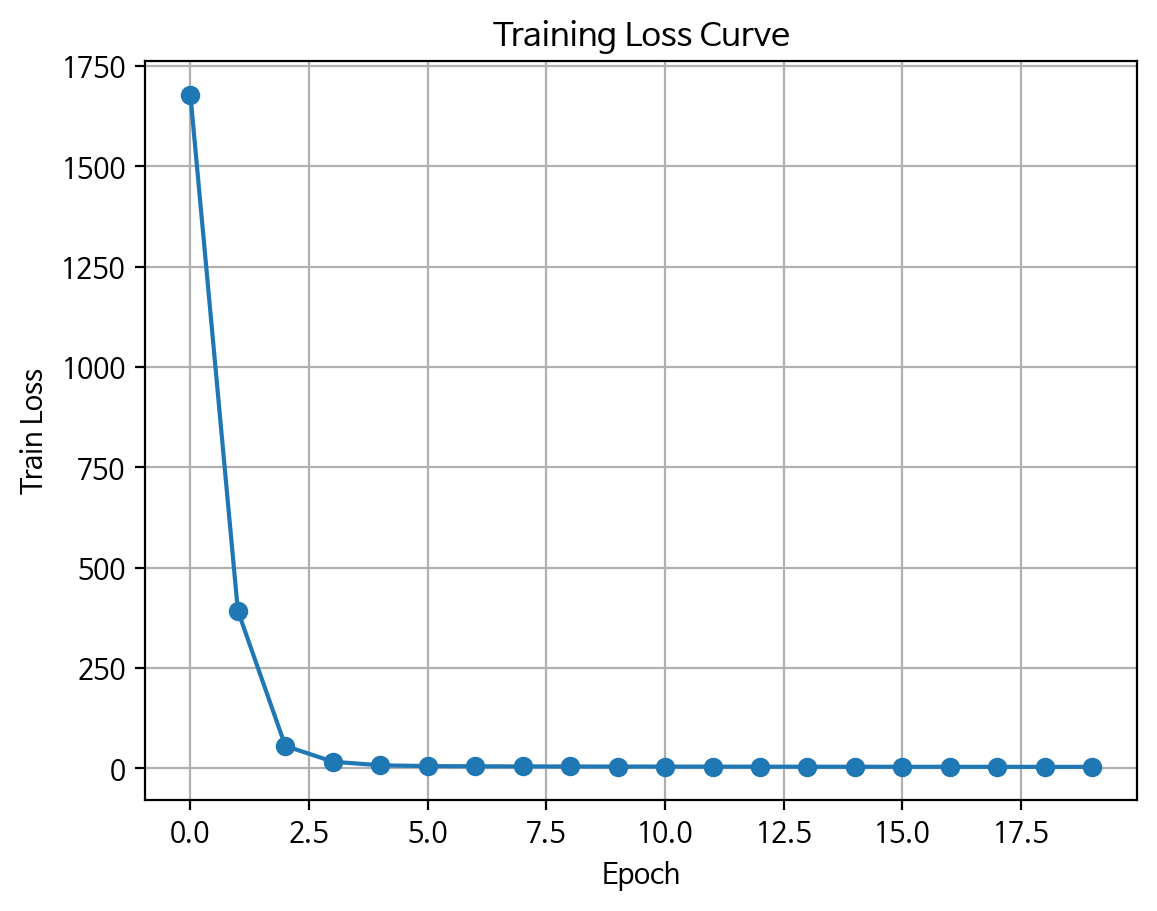

In [76]:
# =========================================
# 9. 학습 루프
# =========================================
examples = [
    "오늘 기분이 어때?",
    "너는 누구니?",
    "점심 뭐 먹을까?",
]

def sample_next_id(logits, temperature=0.8, top_k=20):
    """
    logits: (Vocab_Size,) 크기의 예측값
    temperature: 높을수록 창의적(무작위), 낮을수록 보수적(정확)
    top_k: 확률 상위 K개만 후보로 남김
    """
    # logits: (V,)
    logits = logits / temperature

    if top_k is not None and top_k > 0:
        values, indices = torch.topk(logits, top_k)          # 상위 k개
        probs = torch.zeros_like(logits)
        # 상위 k개 외에는 확률을 0으로 만들어버림 (Noise 제거)
        probs.scatter_(0, indices, F.softmax(values, dim=0)) # 나머지는 0
    else:
        probs = F.softmax(logits, dim=0)

    # 설정된 확률 분포를 바탕으로 다음 단어를 무작위 선택
    next_id = torch.multinomial(probs, num_samples=1).item()
    return next_id

def generate_with_attention(query, max_len=MAX_LEN):
    """입력 문장에 대해 답변을 생성하고 어텐션 맵을 반환합니다."""
    model.eval()
    with torch.no_grad():
        # 전처리 단계 (토큰화 -> 인코딩 -> 패딩)
        q_clean = clean_korean_text(query)
        q_tokens = kiwi_tokenize(q_clean)
        q_join = join_tokens(q_tokens)
        q_ids = encode_sentence(q_join)

        if len(q_ids) > max_len:
            q_ids = q_ids[:max_len]
        q_ids = q_ids + [0] * (max_len - len(q_ids))

        src = torch.tensor([q_ids], dtype=torch.long, device=device)

        out_ids = [1]  # 시작 토큰(BOS)으로 생성 시작

        # 반복 제어 변수 초기화
        repeat_cnt = 0
        max_repeat = 3
        window = 4

        for _ in range(max_len - 1):
            tgt_in = torch.tensor([out_ids], dtype=torch.long, device=device)
            enc_mask, dec_mask, encdec_mask = generate_masks(src, tgt_in)
            # 모델 예측
            logits, enc_attns, dec_attns, decenc_attns = model(
                src, tgt_in, enc_mask, dec_mask, encdec_mask
            )

            # top‑k + temperature 샘플링 - 마지막 타임스텝의 결과로 다음 단어 샘플링
            next_id = sample_next_id(
                logits[0, -1], temperature=0.8, top_k=20
            )

            # [반복 방지 로직] 최근 window 길이 안에 이미 등장한 토큰이면 반복 카운트
            recent = out_ids[-window:]
            if next_id in recent:
                repeat_cnt += 1
            else:
                repeat_cnt = 0

            # 종료 조건: EOS(2)가 나오거나, 무한 반복이 감지될 때
            if next_id == 2:  # EOS
                break
            if repeat_cnt >= max_repeat:
                break

            out_ids.append(next_id)

        # ID를 다시 텍스트로 변환
        decoded = tokenizer.DecodeIds(out_ids[1:])
        src_pieces = tokenizer.IdToPiece(q_ids)
        tgt_pieces = tokenizer.IdToPiece(out_ids[1:])
        return decoded, src_pieces, tgt_pieces, enc_attns, dec_attns, decenc_attns

# --- 본격적인 학습 시작 ---
epoch_losses = []

global_step = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    step = 0

    current_lr = scheduler.get_last_lr()[0]
    print(f"[Epoch {epoch}] lr(start) = {current_lr:.6e}")

    for src, tgt in tqdm(train_loader, desc=f"Epoch {epoch}"):
        src = src.to(device)
        tgt = tgt.to(device)

        # Teacher Forcing을 위해 입력(tgt_in)과 정답(tgt_out)을 1칸씩 밀어 생성
        tgt_in = tgt[:, :-1]    # <sos> ~ 단어_n-1
        tgt_out = tgt[:, 1:]    #  단어_1 ~ <eos>

        if step == 0 and epoch == 1:
            print("tgt_out min / max:", tgt_out.min().item(), tgt_out.max().item())
            print("VOCAB_SIZE:", VOCAB_SIZE)

        enc_mask, dec_mask, encdec_mask = generate_masks(src, tgt_in)

        base_optimizer.zero_grad()
        logits, _, _, _ = model(src, tgt_in, enc_mask, dec_mask, encdec_mask)

        loss = loss_function(tgt_out, logits)
        loss.backward()

        # 그래디언트 폭주 방지 (Gradient Clipping)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        base_optimizer.step()
        scheduler.step()  # 매 스텝마다 학습률 조정 ← 여기가 핵심[web:11][web:15]

        total_loss += loss.item()
        step += 1
        global_step += 1

    avg_loss = total_loss / step
    epoch_losses.append(avg_loss)
    print(f"[Epoch {epoch}] Train Loss: {avg_loss:.4f}")

    # 샘플 Q/A 출력
    print("=== 샘플 질의응답 ===")
    model.eval()
    for q in examples:
        ans, _, _, _, _, _ = generate_with_attention(q)
        print("Q:", q)
        print("A:", ans)
        print("----------------------")

# 손실 곡선
plt.figure()
plt.plot(epoch_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()


### 10. BLEU 평가 + Attention 시각화

=== BLEU 예시 ===
Source : 12시 땡!
Target : 하루가 또 가네요.
Pred   : 좋 은 선택 을 하 어 보 세요 .
BLEU   : 0
Source : 1지망 학교 떨어졌어
Target : 위로해 드립니다.
Pred   : 사랑 이 나 ᆫ 거 예요 .
BLEU   : 0
Source : 3박4일 놀러가고 싶다
Target : 여행은 언제나 좋죠.
Pred   : 참 좋 은 것 같 어요 보 .
BLEU   : 0
Q: 오늘 기분이 어때?
A: 아무 생각 하 세요 .


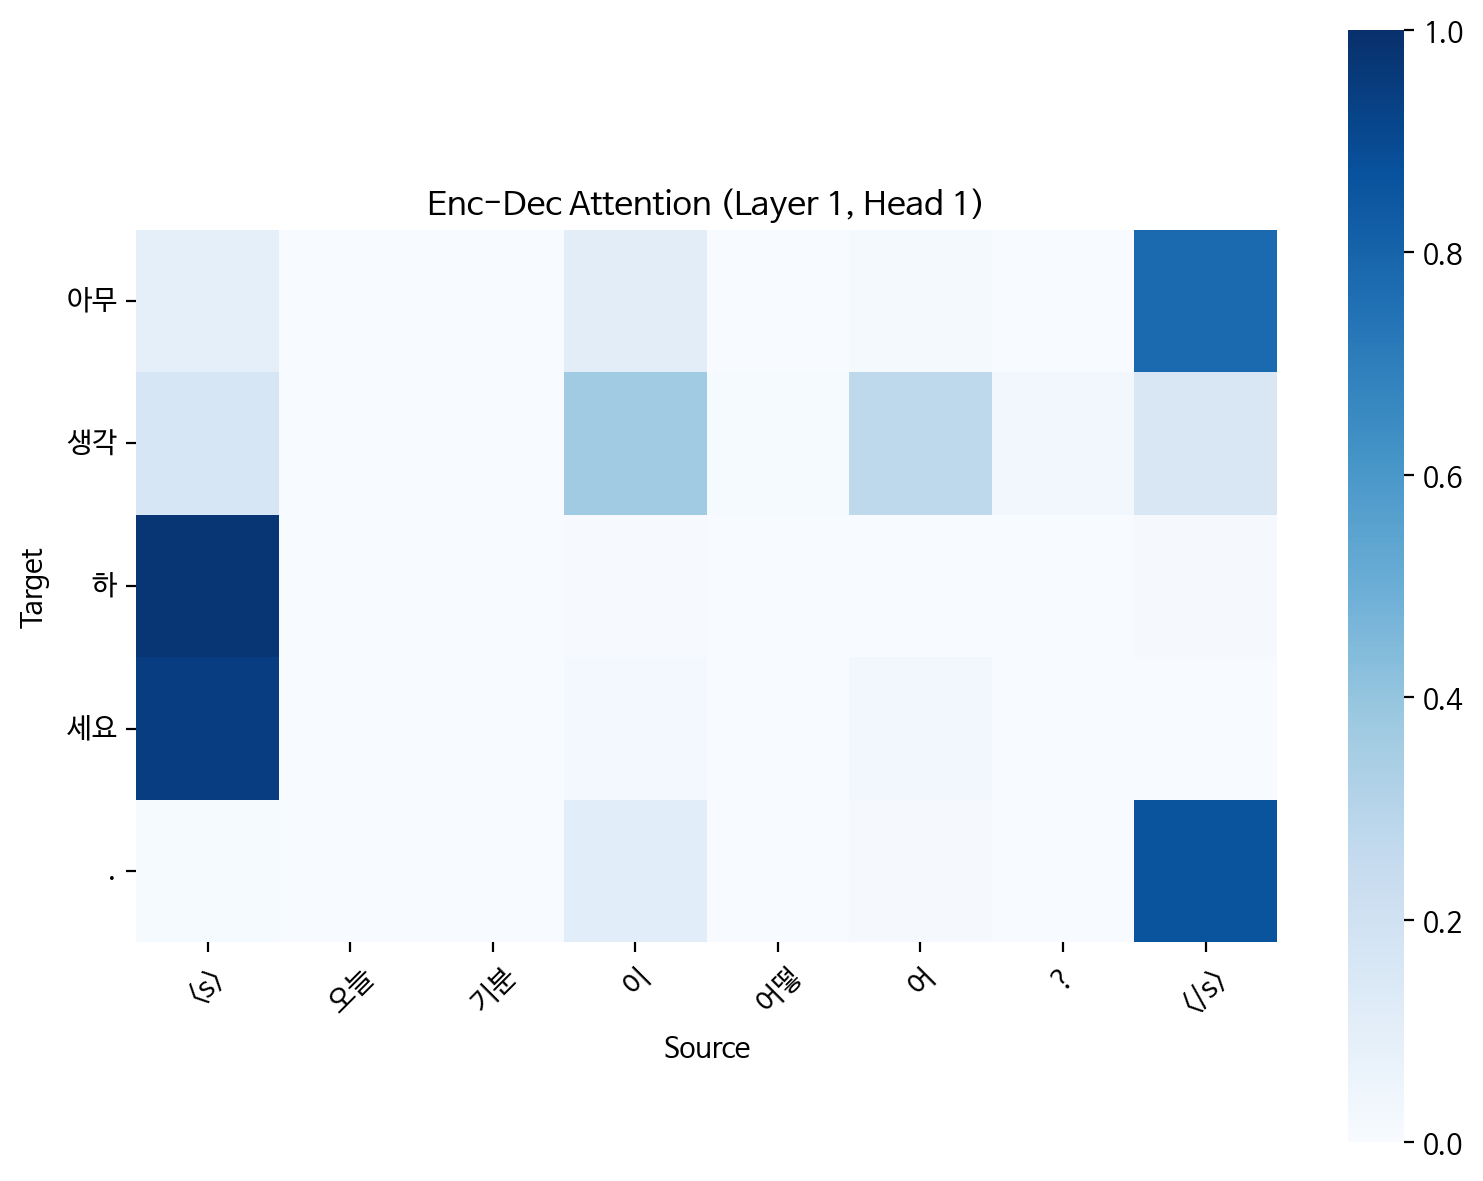

In [77]:
# =========================================
# 10. BLEU 평가 + Attention 시각화 예시
# =========================================
def eval_bleu_one(src_text, tgt_text, verbose=True):
    model.eval()
    pred, _, _, _, _, _ = generate_with_attention(src_text)
    ref = tgt_text.split()
    hyp = pred.split()
    smooth = SmoothingFunction().method1
    score = sentence_bleu([ref], hyp, smoothing_function=smooth)
    if verbose:
        print("Source :", src_text)
        print("Target :", tgt_text)
        print("Pred   :", pred)
        print("BLEU   :", score)
    return score

print("=== BLEU 예시 ===")
for i in range(3):
    src = df["Q_clean"].iloc[i]
    tgt = df["A_clean"].iloc[i]
    eval_bleu_one(src, tgt)

### Attention 시각화 1회 실행
q = "오늘 기분이 어때?"
pred, src_p, tgt_p, enc_attns, dec_attns, decenc_attns = generate_with_attention(q)
print("Q:", q)
print("A:", pred)
visualize_attention(src_p, tgt_p, enc_attns, dec_attns, decenc_attns)
# for l in range(len(decenc_attns)):
#     for h in range(decenc_attns[l].size(1)):
#         print(f"Layer {l+1}, Head {h+1}")
#         visualize_attention(src_p, tgt_p, enc_attns, dec_attns, decenc_attns, layer=l, head=h)


## 챗봇

In [79]:
import torch
import sys

# 만약 로컬 환경에서 실제 ESC 키를 감지하고 싶다면 아래 라이브러리가 필요합니다.
# !pip install keyboard
try:
    import keyboard
except ImportError:
    keyboard = None

def start_chatting(model, tokenizer, device, max_len=40):
    """
    학습된 모델과 대화를 나누는 루프를 실행합니다.
    """
    model.eval()  # 평가 모드 전환

    print("="*50)
    print("   나만의 트랜스포머 챗봇과 대화를 시작합니다!")
    print("   (종료하려면 'esc'를 입력하거나 ESC 키를 누르세요)")
    print("="*50)

    while True:
        # 1. 사용자 입력 받기
        user_input = input("\n나: ").strip()

        # 2. 종료 조건 체크 (입력값이 'esc'이거나 키보드 이벤트 발생 시)
        if user_input.lower() == 'esc':
            print("\n챗봇: 다음에 또 봐요! 안녕~")
            break

        # 키보드 라이브러리가 설치된 경우 ESC 키 눌림 감지
        if keyboard and keyboard.is_pressed('esc'):
            print("\n챗봇: ESC 신호를 확인했어요. 종료합니다!")
            break

        if not user_input:
            continue

        # 3. 답변 생성
        # 반환값: decoded, src_pieces, tgt_pieces, enc_attns, dec_attns, decenc_attns
        try:
            response, _, _, _, _, _ = generate_with_attention(
                user_input,
                max_len=max_len
            )

            print(f"챗봇: {response}")

        except Exception as e:
            print(f"에러가 발생했어요: {e}")

# 챗봇 실행
# (이미 model, tokenizer, device가 메모리에 로드되어 있어야 합니다)
start_chatting(model, tokenizer, device)

   나만의 트랜스포머 챗봇과 대화를 시작합니다!
   (종료하려면 'esc'를 입력하거나 ESC 키를 누르세요)

나: 저녁 뭐 먹지?
챗봇: 맛있 는 것 이 좋 을 거 같 어요 고 있 .

나: 맛있는 음식 뭐?
챗봇: 저 는 알 ᆯ 수 있 어요 .

나: 그래 너가 아는 맛있는 음식을 말해줘
챗봇: 사랑 을  ⁇ 

나: 사랑은 먹는게 아니야
챗봇: 사랑 을 사랑 하 는 것 이 아니 ᆫ 거 ᆯ 수 도 있 어요 .

나: 너랑 대화하다보면 대화가 자꾸 딴길로 새는 것 같아
챗봇: 새롭 은 좋 을 거 같 어요 .

나: 너는 참 긍정적이구나
챗봇: 저 도 그렇 죠 .

나: 이만 헤어져
챗봇: 많이 헷갈리 는 거 시 기 마련 이 . 예요

나: 헤어지자고!
챗봇: 마음 이 별 은 많 다고 하 세요 .

나: 헤저지자고!
챗봇: 후회 하 ᆫ 일 이 ᆯ 수 있 어요 .

나: 후회 안해
챗봇: 잘 되 ᆯ 거 이 예요 .

나: 그래 너도 우리가 이별하는 게 좋을 것 같지?
챗봇: 이별 을 비교 하 ᆫ 이 ᆯ 수 도 있 어요 .

나: 이별을 어떻게 비교하니?
챗봇: 종 거나 서로 의 종교 하 겠 죠 .

나: 이만 안녕
챗봇: 시간 이 잘 하 시 ᆯ 거 이 예요 .

나: esc

챗봇: 다음에 또 봐요! 안녕~
